In [1]:
%matplotlib inline 

In [3]:
!pip install opencv-python


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import os
import numpy as np
from keras.utils import to_categorical
from keras.preprocessing import image
from keras.models import load_model
from keras.models import save_model

In [5]:
img = image.load_img(r"C:\Users\Shanuka\Desktop\Color blindness-detection\basedata\testing\0\3.jpg")

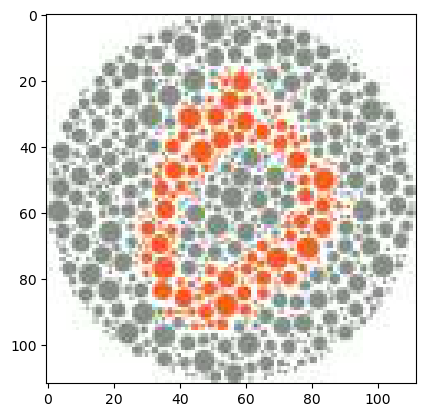

In [6]:
plt.imshow(img)

In [7]:
cv2.imread(r"C:\Users\Shanuka\Desktop\Color blindness-detection\basedata\testing\0\3.jpg").shape

(112, 112, 3)

In [9]:
train = ImageDataGenerator(rescale= 1/255)
validation = ImageDataGenerator(rescale= 1/255)

In [10]:
train_dataset = train.flow_from_directory(
    r"C:\Users\Shanuka\Desktop\Color blindness-detection\basedata\training",
    target_size=(200, 200),
    batch_size=3,
    class_mode='categorical',  # Keep this as categorical
    shuffle=True
)

validation_dataset = train.flow_from_directory(
    r"C:\Users\Shanuka\Desktop\Color blindness-detection\basedata\validation",
    target_size=(200, 200),
    batch_size=3,
    class_mode='categorical',
    shuffle=False
)


Found 1783 images belonging to 10 classes.
Found 1783 images belonging to 10 classes.


In [11]:
train_dataset.class_indices

{'0': 0,
 '1': 1,
 '2': 2,
 '3': 3,
 '4': 4,
 '5': 5,
 '6': 6,
 '7': 7,
 '8': 8,
 '9': 9}

In [12]:
train_dataset.classes

array([0, 0, 0, ..., 9, 9, 9])

In [13]:
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()



Instructions for updating:
non-resource variables are not supported in the long term


In [14]:
model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(200, 200, 3)),
    MaxPool2D(2, 2),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPool2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPool2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dense(10, activation='softmax')
])

In [15]:
optimizer = tf.keras.optimizers.RMSprop()

In [16]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [16]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 198, 198, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2  (None, 99, 99, 16)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 97, 97, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 48, 48, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 46, 46, 64)        18496     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 23, 23, 64)        0

In [23]:
!pip install --upgrade tensorflow


^C


In [17]:
model.fit(
    train_dataset,
    steps_per_epoch=len(train_dataset),
    epochs=10,
    validation_data=validation_dataset,
    validation_steps=len(validation_dataset)
)


Epoch 1/10

595/595 [==============================] - ETA: 0s - batch: 297.0000 - size: 2.9966 - loss: 1.0009 - acc: 0.7241

C:\Users\Shanuka\anaconda3\Lib\site-packages\keras\src\engine\training_v1.py:2335: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates = self.state_updates


595/595 [==============================] - 67s 111ms/step - batch: 297.0000 - size: 2.9966 - loss: 1.0009 - acc: 0.7241 - val_loss: 0.2564 - val_acc: 0.9226
Epoch 2/10
595/595 [==============================] - 51s 86ms/step - batch: 297.0000 - size: 2.9966 - loss: 0.2724 - acc: 0.9237 - val_loss: 0.0934 - val_acc: 0.9736
Epoch 3/10
595/595 [==============================] - 52s 87ms/step - batch: 297.0000 - size: 2.9966 - loss: 0.1105 - acc: 0.9647 - val_loss: 0.0449 - val_acc: 0.9849
Epoch 4/10
595/595 [==============================] - 52s 87ms/step - batch: 297.0000 - size: 2.9966 - loss: 0.0523 - acc: 0.9843 - val_loss: 0.0684 - val_acc: 0.9804
Epoch 5/10
595/595 [==============================] - 54s 90ms/step - batch: 297.0000 - size: 2.9966 - loss: 0.0337 - acc: 0.9910 - val_loss: 0.0142 - val_acc: 0.9950
Epoch 6/10
595/595 [==============================] - 54s 91ms/step - batch: 297.0000 - size: 2.9966 - loss: 0.0050 - acc: 0.9978 - val_loss: 8.5874e-04 - val_acc: 0.9994
Epoc

In [18]:
validation_dataset.class_indices

{'0': 0,
 '1': 1,
 '2': 2,
 '3': 3,
 '4': 4,
 '5': 5,
 '6': 6,
 '7': 7,
 '8': 8,
 '9': 9}

In [19]:
dir_path = r'C:\Users\Shanuka\Desktop\Color blindness-detection\basedata\training'

for class_folder in os.listdir(dir_path):
    class_path = os.path.join(dir_path, class_folder)
    print(f"Class {class_folder} contents:")
    
    for img_filename in os.listdir(class_path):
        img_path = os.path.join(class_path, img_filename)
        img = image.load_img(img_path, target_size=(200, 200, 3))
        x = image.img_to_array(img)
        x = np.expand_dims(x, axis=0)
        images = np.vstack([x])
        
        # Assuming `model` is your trained model
        predictions = model.predict(images)
        predicted_class = np.argmax(predictions)
        
        print(f"Image: {img_filename}, Predicted Class: {predicted_class}")

Class 0 contents:
Image: 10.jpg, Predicted Class: 0
Image: 1001.jpg, Predicted Class: 0
Image: 1009.jpg, Predicted Class: 0
Image: 101.jpg, Predicted Class: 0
Image: 1034.jpg, Predicted Class: 0
Image: 1047.jpg, Predicted Class: 0
Image: 1061.jpg, Predicted Class: 0
Image: 1084.jpg, Predicted Class: 0
Image: 1094.jpg, Predicted Class: 0
Image: 1121.jpg, Predicted Class: 0


C:\Users\Shanuka\anaconda3\Lib\site-packages\keras\src\engine\training_v1.py:2359: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


Image: 1148.jpg, Predicted Class: 0
Image: 1154.jpg, Predicted Class: 0
Image: 1176.jpg, Predicted Class: 0
Image: 1188.jpg, Predicted Class: 0
Image: 1191.jpg, Predicted Class: 0
Image: 1195.jpg, Predicted Class: 0
Image: 1197.jpg, Predicted Class: 0
Image: 1203.jpg, Predicted Class: 0
Image: 1218.jpg, Predicted Class: 0
Image: 1220.jpg, Predicted Class: 0
Image: 1223.jpg, Predicted Class: 0
Image: 1231.jpg, Predicted Class: 0
Image: 1246.jpg, Predicted Class: 0
Image: 126.jpg, Predicted Class: 0
Image: 1261.jpg, Predicted Class: 0
Image: 1271.jpg, Predicted Class: 0
Image: 1273.jpg, Predicted Class: 0
Image: 1288.jpg, Predicted Class: 0
Image: 1294.jpg, Predicted Class: 0
Image: 1297.jpg, Predicted Class: 0
Image: 13.jpg, Predicted Class: 0
Image: 1333.jpg, Predicted Class: 0
Image: 136.jpg, Predicted Class: 0
Image: 1379.jpg, Predicted Class: 0
Image: 1390.jpg, Predicted Class: 0
Image: 1399.jpg, Predicted Class: 0
Image: 1404.jpg, Predicted Class: 0
Image: 1408.jpg, Predicted Class

Displaying 3 images from Class 0:


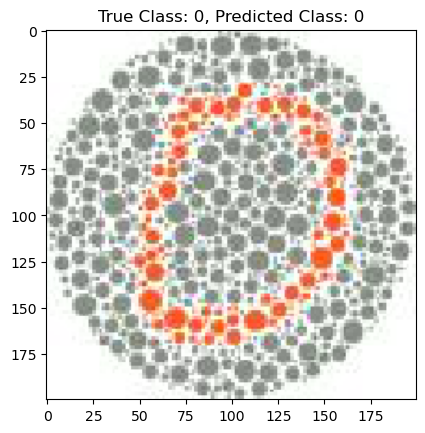

Prediction is correct!



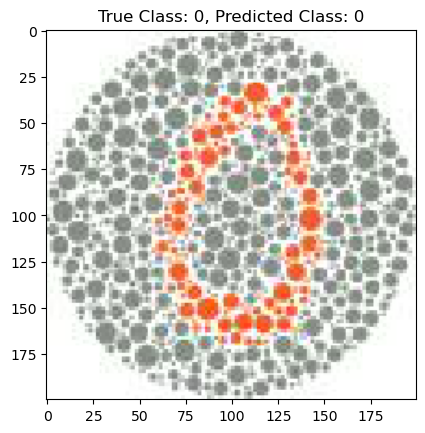

Prediction is correct!



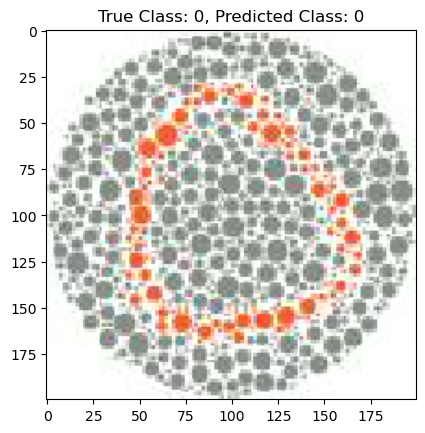

Prediction is correct!

Displaying 3 images from Class 1:


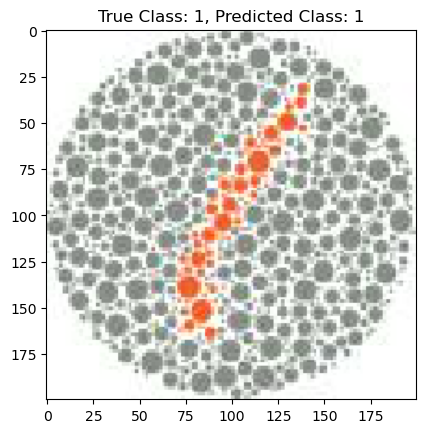

Prediction is correct!



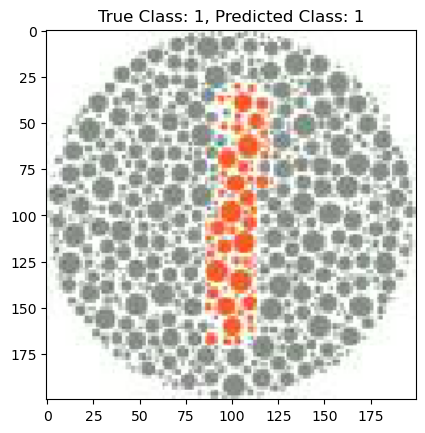

Prediction is correct!



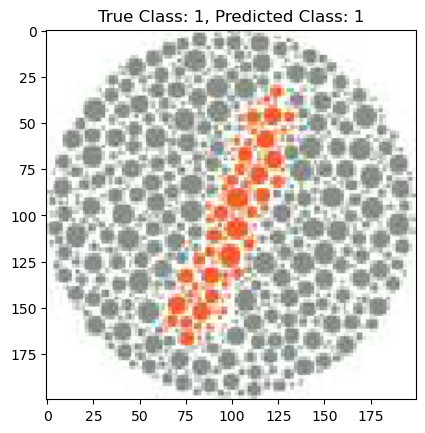

Prediction is correct!

Displaying 3 images from Class 2:


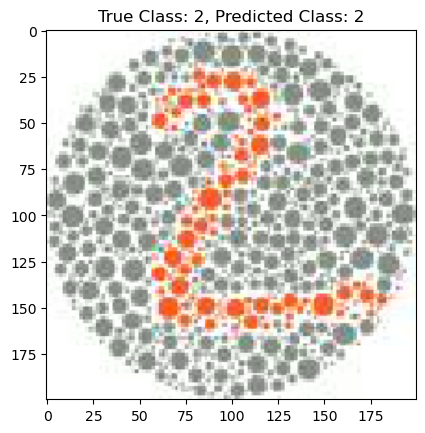

Prediction is correct!



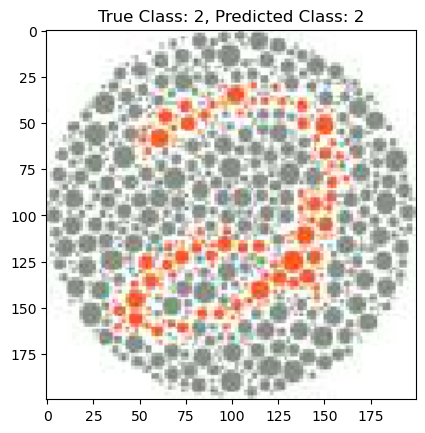

Prediction is correct!



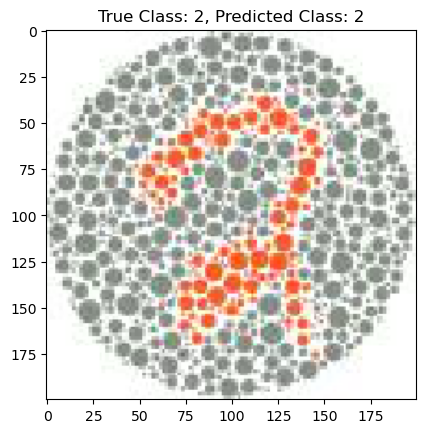

Prediction is correct!

Displaying 3 images from Class 3:


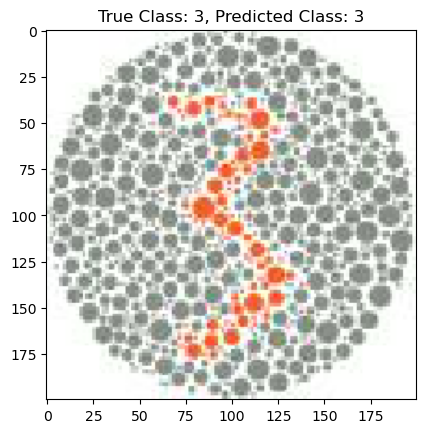

Prediction is correct!



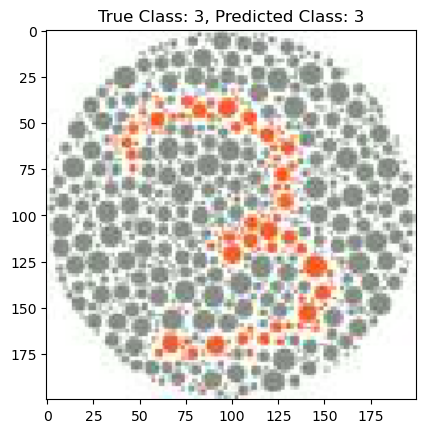

Prediction is correct!



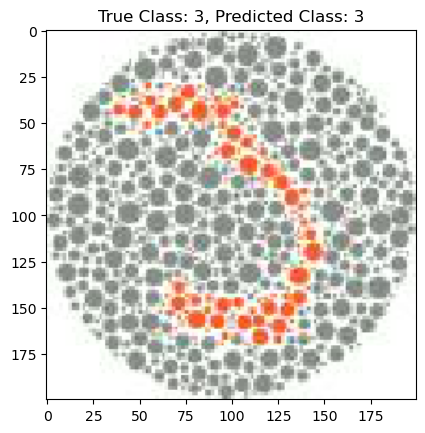

Prediction is correct!

Displaying 3 images from Class 4:


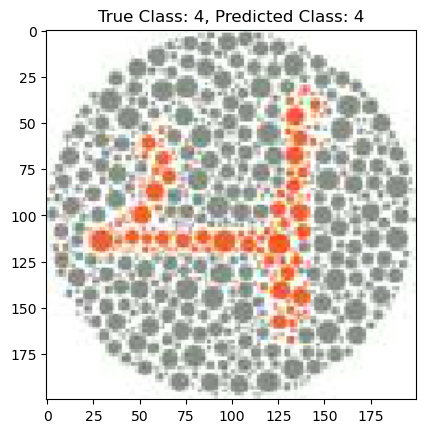

Prediction is correct!



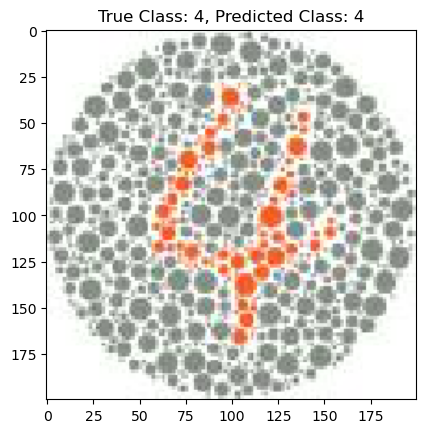

Prediction is correct!



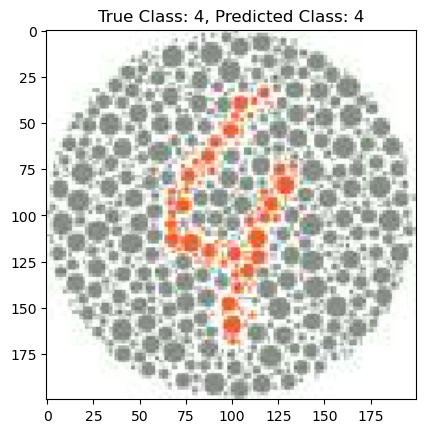

Prediction is correct!

Displaying 3 images from Class 5:


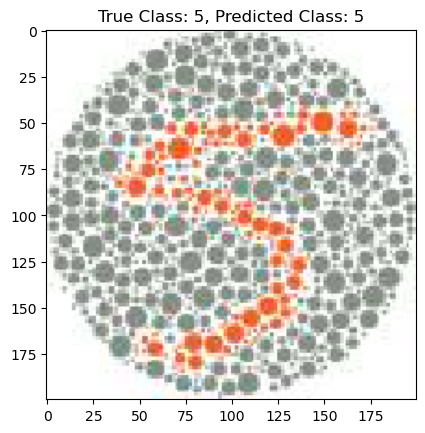

Prediction is correct!



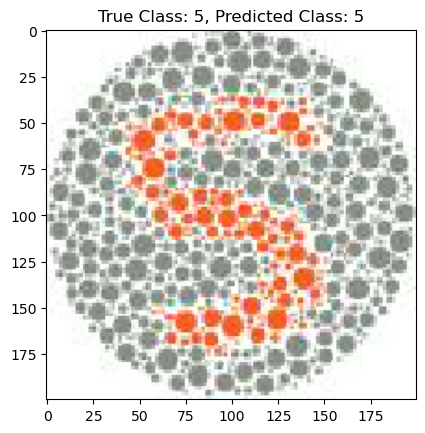

Prediction is correct!



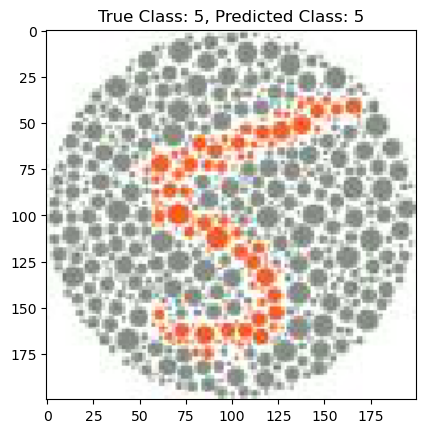

Prediction is correct!

Displaying 3 images from Class 6:


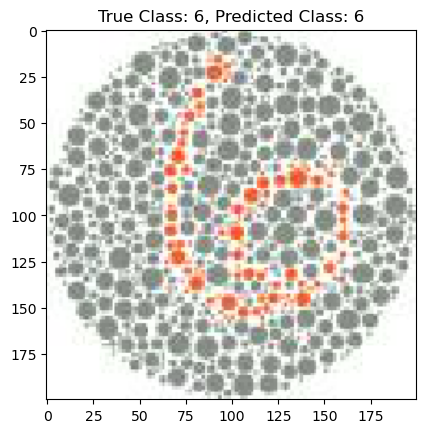

Prediction is correct!



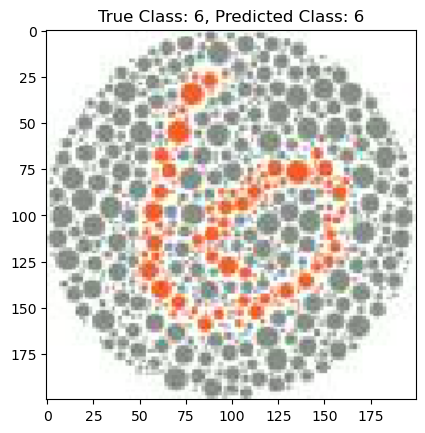

Prediction is correct!



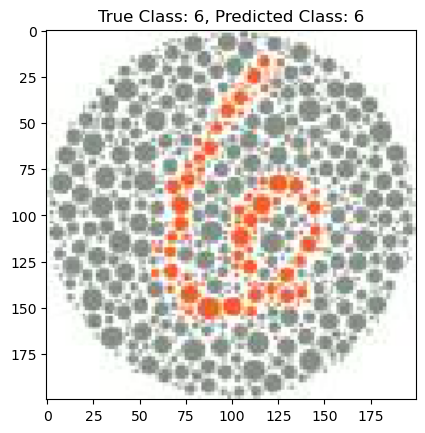

Prediction is correct!

Displaying 3 images from Class 7:


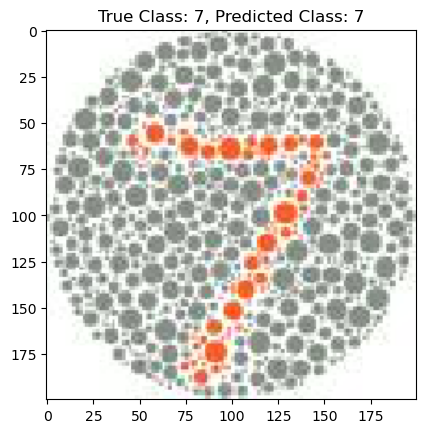

Prediction is correct!



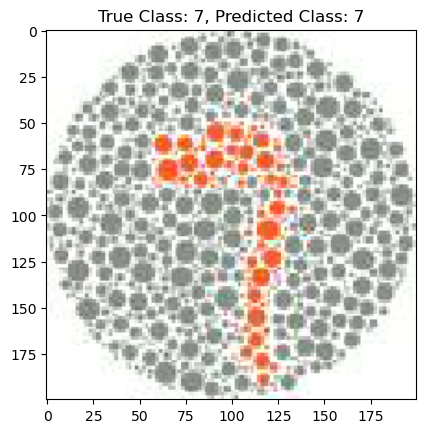

Prediction is correct!



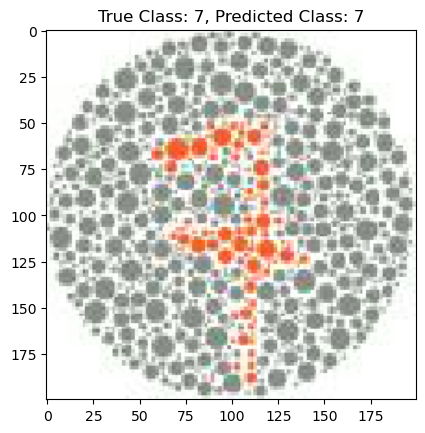

Prediction is correct!

Displaying 3 images from Class 8:


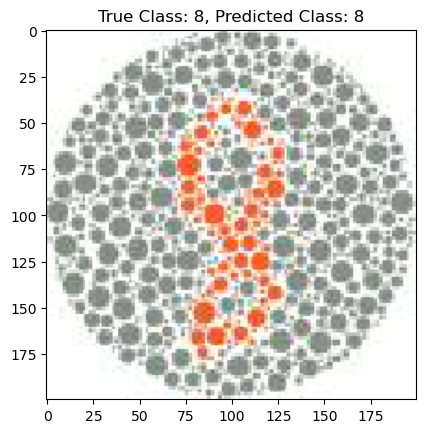

Prediction is correct!



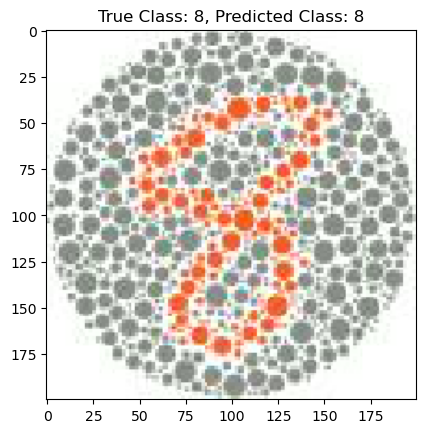

Prediction is correct!



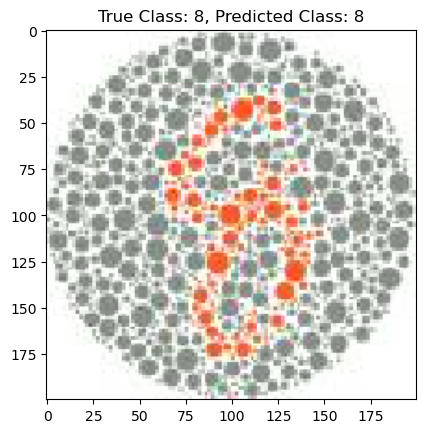

Prediction is correct!

Displaying 3 images from Class 9:


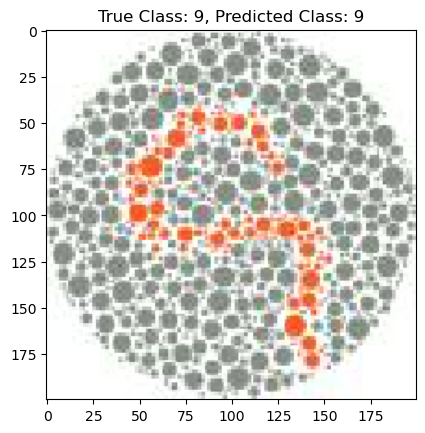

Prediction is correct!



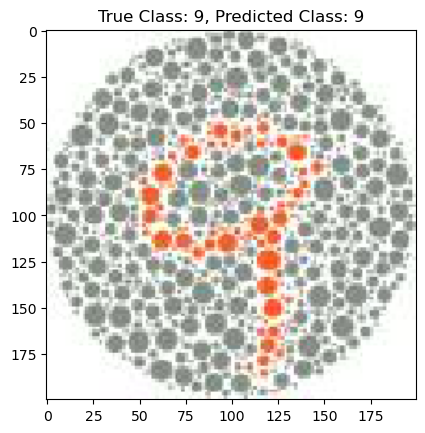

Prediction is correct!



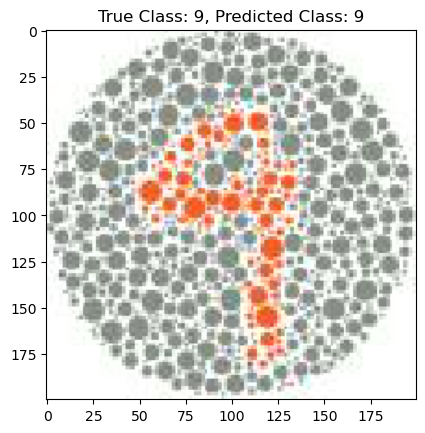

Prediction is correct!



In [27]:
dir_path = r'C:\Users\Shanuka\Desktop\Color blindness-detection\basedata\training'
num_images_to_display = 3

for class_folder in os.listdir(dir_path):
    class_path = os.path.join(dir_path, class_folder)
    print(f"Displaying {num_images_to_display} images from Class {class_folder}:")
    
    image_files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
    
    for img_filename in image_files[:num_images_to_display]:
        img_path = os.path.join(class_path, img_filename)
        img = image.load_img(img_path, target_size=(200, 200))
        img_array = image.img_to_array(img)
        
        # Assuming `model` is your trained model
        predictions = model.predict(np.expand_dims(img_array, axis=0))
        predicted_class = np.argmax(predictions)
        
        plt.imshow(np.uint8(img_array))
        plt.title(f"True Class: {class_folder}, Predicted Class: {predicted_class}")
        plt.show()
        
        if int(class_folder) == predicted_class:
            print("Prediction is correct!\n")
        else:
            print("Misclassification!\n")


In [55]:
from tensorflow.keras.models import save_model



In [56]:

# Assuming your model is named 'model'
model.save("Detection2_phase1.h5")

In [57]:
from tensorflow.keras.models import load_model

In [59]:
loaded_model = load_model('Detection2_phase1.h5')

In [60]:
loaded_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 198, 198, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2  (None, 99, 99, 16)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 97, 97, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 48, 48, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 46, 46, 64)        18496     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 23, 23, 64)        0

In [61]:
print(dir(loaded_model))


['_SCALAR_UPRANKING_ON', '_TF_MODULE_IGNORED_PROPERTIES', '__annotations__', '__call__', '__class__', '__copy__', '__deepcopy__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_activity_regularizer', '_add_trackable', '_add_trackable_child', '_add_unique_metric_name', '_add_variable_with_custom_getter', '_aggregate_exact_metrics', '_assert_built_as_v1', '_assert_compile_was_called', '_assert_weights_created', '_auto_config', '_auto_get_config', '_auto_track_sub_layers', '_autocast', '_autographed_call', '_autotune_steps_per_execution', '_base_model_initialized', '_build_graph_network_for_inferred_shape', '_build_input_shape', '_build_model_with_inputs', '_cache_output_metri

In [62]:
print(type(loaded_model))


<class 'keras.src.engine.sequential.Sequential'>


In [63]:
import pickle

In [64]:
import tensorflow as tf
tf.config.run_functions_eagerly(True)


In [65]:
from tensorflow.keras.models import load_model
import numpy as np
from PIL import Image

# Load the saved model
loaded_model = load_model('Detection2_phase1.h5')

# Preprocess your test image
# Example: Load and preprocess a single test image
image_path = r'C:\Users\Shanuka\Desktop\Color blindness-detection\basedata\testing\0\3.jpg'
image = Image.open(image_path)
image = image.resize((198, 198))  # Resize to match the input dimensions of your model
image = np.array(image) / 255.0    # Normalize pixel values

# Make predictions
# Ensure your test data is in the correct shape expected by your model
# For example, if your model expects a batch dimension, you might need to add it:
# image = np.expand_dims(image, axis=0)
predictions = loaded_model.predict(np.array([image]))

# Interpret the predictions
# You may need to map the predicted class indices to their corresponding labels
# Depending on your model, you might have a separate file that maps class indices to class labels
# For example, if your model outputs probabilities, you can get the predicted class index as follows:
predicted_class_index = np.argmax(predictions)
print("Predicted Class Index:", predicted_class_index)

# Display the predicted class label
# Here you need to map the predicted class index to your class labels
class_labels = ['class1', 'class2', 'class3', ...]  # Define your class labels
predicted_class_label = class_labels[predicted_class_index]
print("Predicted Class Label:", predicted_class_label)


ValueError: Input 0 of layer "sequential" is incompatible with the layer: expected shape=(None, 200, 200, 3), found shape=(1, 198, 198, 3)

In [66]:
from tensorflow.keras.models import load_model
import numpy as np
from PIL import Image

# Load the saved model
loaded_model = load_model('Detection2_phase1.h5')

# Preprocess your test image
image_path = r'C:\Users\Shanuka\Desktop\Color blindness-detection\basedata\testing\0\3.jpg'
image = Image.open(image_path)
image = image.resize((200, 200))  # Resize to match the input dimensions of your model
image = np.array(image) / 255.0    # Normalize pixel values
image = np.expand_dims(image, axis=0)  # Add an extra dimension for batch size

# Make predictions
predictions = loaded_model.predict(image)

# Interpret the predictions
predicted_class_index = np.argmax(predictions)
print("Predicted Class Index:", predicted_class_index)


RuntimeError: Attempted to aggregate unsupported object Tensor("sequential/dense_1/Softmax:0", shape=(1, 10), dtype=float32).

In [67]:
import numpy as np
from keras.models import load_model
from keras.preprocessing import image

# Load the saved model
loaded_model = load_model('Detection2_phase1.h5')

# Define the path to the image you want to test
image_path = r'C:\Users\Shanuka\Desktop\Color blindness-detection\basedata\testing\0\3.jpg'

# Load and preprocess the image
img = image.load_img(image_path, target_size=(200, 200))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Add an extra dimension for batch size
img_array /= 255.0  # Normalize pixel values

# Make predictions
predictions = loaded_model.predict(img_array)

# Extract the predicted class index
predicted_class_index = np.argmax(predictions[0])
print("Predicted Class Index:", predicted_class_index)


RuntimeError: Attempted to aggregate unsupported object Tensor("sequential_1/dense_1/Softmax:0", shape=(1, 10), dtype=float32).